In [1]:
import numpy as np

import torch
import torch.nn as nn
import pandas as pd
import os
import importlib
import sys
from tqdm import tqdm
from torchvision import transforms
import torchvision.models as models 
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

batch_size = 256

import torchsummary


torch.manual_seed(42)

In [2]:
# 1. Konfiguration
REPO_URL = "https://github.com/828w5tjjts-wq/Machine-Learning-Final-project.git"
PROJECT_DIR = "/kaggle/working/Machine-Learning-Final-project"

# 2. Prüfen, ob das Repo schon existiert
if os.path.exists(PROJECT_DIR):
    print("Repo existiert bereits. Ziehe neueste Änderungen (Pull)...")
    %cd {PROJECT_DIR}
    !git pull origin main
else:
    print("Repo existiert nicht. Klone von GitHub...")
    !git clone {REPO_URL} {PROJECT_DIR}
    %cd {PROJECT_DIR}

# 3. Pfad zum System-Pfad hinzufügen (damit Imports funktionieren)
sys.path.append(PROJECT_DIR)

print("Setup abgeschlossen. Projekt ist aktuell.")

Repo existiert nicht. Klone von GitHub...
Cloning into '/kaggle/working/Machine-Learning-Final-project'...
remote: Enumerating objects: 138, done.
remote: Counting objects: 100% (138/138), done.
remote: Compressing objects: 100% (102/102), done.
remote: Total 138 (delta 54), reused 94 (delta 28), pack-reused 0 (from 0)
Receiving objects: 100% (138/138), 127.71 KiB | 1.64 MiB/s, done.
Resolving deltas: 100% (54/54), done.
/kaggle/working/Machine-Learning-Final-project
Setup abgeschlossen. Projekt ist aktuell.


In [3]:
from src.models.architectures import MLPModel
from src.models.architectures import MLPModel_V2
from src.models.architectures import MLPModel_V3
from src.models.trainer import run_training
from src.data.loader import prepare_data
from src.data.loader import load_processed_data
from src.data.edit import split_data
from src.data.edit import standardize_data
from src.data.dataset import create_dataloaders
from src.models.tune import test_learning_rates
from src.models.trainer import train_model_with_early_stopping
from src.data.cleaner import clean_target
from src.data.dataset import create_dataloaders

In [4]:
# DO NOT CHANGE
use_cuda = True
use_cuda = False if not use_cuda else torch.cuda.is_available()
device = torch.device('cuda:0' if use_cuda else 'cpu')
torch.cuda.get_device_name(device) if use_cuda else 'cpu'
print('Using device', device)

Using device cpu


In [5]:
X_raw, y = load_processed_data('/kaggle/input/datasets/nilsmatthiessen/processed-data/Machine-Learning-Final-project/X_filtered.npy'
,'/kaggle/input/datasets/nilsmatthiessen/processed-data/Machine-Learning-Final-project/y.npy' )

X_train, X_val, X_test, y_train, y_val, y_test = split_data(X_raw, y)
X_train_scaled, X_val_scaled, X_test_scaled = standardize_data(X_train, X_val, X_test)
    
train_loader, val_loader, test_loader = create_dataloaders(
    X_train_scaled, X_val_scaled, X_test_scaled, 
    y_train, y_val, y_test, 
    batch_size=batch_size
    )
print("\nAlles bereit für das Training!")

sample_inputs, _ = next(iter(train_loader))
input_dim = sample_inputs.shape[1]

model_linear = MLPModel(input_dim, 1)
model_linear = model_linear.to(device)

loss_function = torch.nn.MSELoss() # Mean Squared Error für Regression
optimizer = torch.optim.Adam(model_linear.parameters(), lr=0.1) 
num_epochs = 100


Daten geladen: X Shape (9229, 78), y Shape (9229,)
Split: Train=6460, Val=1384, Test=1385
Scaling abgeschlossen.
DataLoader bereit (Batch Size 256):
  Train Batches: 26
  Val Batches: 6
  Test Batches: 6

Alles bereit für das Training!


In [6]:
model_mlp = MLPModel(input_dim=input_dim, output_dim=1).to(device)

# 2. Loss Function und Optimizer
loss_function = nn.MSELoss()
# Wir probieren 0.01, da MLPs empfindlicher auf große Sprünge reagieren können als lineare Modelle
optimizer = torch.optim.Adam(model_mlp.parameters(), lr=0.1) 


In [7]:
train_losses, val_losses, train_rmses, val_rmses = run_training(
    model=model_mlp,
    optimizer=optimizer,
    loss_function=loss_function,
    device=device,
    num_epochs=50,
    train_dataloader=train_loader,
    val_dataloader=val_loader
)

Starte Training für 50 Epochen...


<div><p>Epoch 1/50 | Train Loss (MSE): 9376.5828 | Train RMSE:       96.83€ | Val Loss (MSE):   2942.2078 | Val RMSE:         55.34€</p><p>Epoch 2/50 | Train Loss (MSE): 5024.7629 | Train RMSE:       71.42€ | Val Loss (MSE):   2851.9968 | Val RMSE:         54.75€</p><p>Epoch 3/50 | Train Loss (MSE): 4011.8181 | Train RMSE:       63.75€ | Val Loss (MSE):   2339.1809 | Val RMSE:         49.63€</p><p>Epoch 4/50 | Train Loss (MSE): 3991.7447 | Train RMSE:       62.84€ | Val Loss (MSE):   2518.8021 | Val RMSE:         51.66€</p><p>Epoch 5/50 | Train Loss (MSE): 3511.0364 | Train RMSE:       59.17€ | Val Loss (MSE):   1831.1188 | Val RMSE:         43.82€</p><p>Epoch 6/50 | Train Loss (MSE): 4180.7446 | Train RMSE:       65.32€ | Val Loss (MSE):   1854.8812 | Val RMSE:         44.27€</p><p>Epoch 7/50 | Train Loss (MSE): 3770.3143 | Train RMSE:       61.14€ | Val Loss (MSE):   8015.0067 | Val RMSE:         90.52€</p><p>Epoch 8/50 | Train Loss (MSE): 4823.8702 | Train RMSE:       67.60€ | Val Loss (MSE):   1156.5410 | Val RMSE:         35.11€</p><p>Epoch 9/50 | Train Loss (MSE): 3759.3327 | Train RMSE:       60.77€ | Val Loss (MSE):   1730.1379 | Val RMSE:         42.23€</p><p>Epoch 10/50 | Train Loss (MSE): 2754.8946 | Train RMSE:       52.86€ | Val Loss (MSE):   995.7947 | Val RMSE:         32.04€</p><p>Epoch 11/50 | Train Loss (MSE): 2150.9486 | Train RMSE:       46.31€ | Val Loss (MSE):   981.0872 | Val RMSE:         31.90€</p><p>Epoch 12/50 | Train Loss (MSE): 3274.7726 | Train RMSE:       57.74€ | Val Loss (MSE):   1093.8704 | Val RMSE:         33.69€</p><p>Epoch 13/50 | Train Loss (MSE): 3120.7017 | Train RMSE:       56.11€ | Val Loss (MSE):   1246.1623 | Val RMSE:         35.81€</p><p>Epoch 14/50 | Train Loss (MSE): 2576.8856 | Train RMSE:       50.03€ | Val Loss (MSE):   948.7529 | Val RMSE:         31.48€</p><p>Epoch 15/50 | Train Loss (MSE): 2473.1140 | Train RMSE:       50.11€ | Val Loss (MSE):   1404.1443 | Val RMSE:         37.90€</p><p>Epoch 16/50 | Train Loss (MSE): 2706.8483 | Train RMSE:       52.41€ | Val Loss (MSE):   822.4684 | Val RMSE:         29.22€</p><p>Epoch 17/50 | Train Loss (MSE): 2350.2803 | Train RMSE:       48.92€ | Val Loss (MSE):   1485.6460 | Val RMSE:         39.40€</p><p>Epoch 18/50 | Train Loss (MSE): 2432.4915 | Train RMSE:       49.54€ | Val Loss (MSE):   743.2470 | Val RMSE:         27.72€</p><p>Epoch 19/50 | Train Loss (MSE): 2515.1652 | Train RMSE:       50.28€ | Val Loss (MSE):   1952.2597 | Val RMSE:         44.66€</p><p>Epoch 20/50 | Train Loss (MSE): 2231.2783 | Train RMSE:       47.61€ | Val Loss (MSE):   1354.4608 | Val RMSE:         36.95€</p><p>Epoch 21/50 | Train Loss (MSE): 2828.7565 | Train RMSE:       53.14€ | Val Loss (MSE):   1205.5394 | Val RMSE:         35.41€</p><p>Epoch 22/50 | Train Loss (MSE): 2304.5382 | Train RMSE:       48.21€ | Val Loss (MSE):   1057.6893 | Val RMSE:         33.11€</p><p>Epoch 23/50 | Train Loss (MSE): 2137.9252 | Train RMSE:       46.54€ | Val Loss (MSE):   961.3471 | Val RMSE:         31.54€</p><p>Epoch 24/50 | Train Loss (MSE): 1897.8438 | Train RMSE:       43.48€ | Val Loss (MSE):   1203.0691 | Val RMSE:         35.21€</p><p>Epoch 25/50 | Train Loss (MSE): 2708.0526 | Train RMSE:       52.59€ | Val Loss (MSE):   1715.1445 | Val RMSE:         42.01€</p><p>Epoch 26/50 | Train Loss (MSE): 2350.0964 | Train RMSE:       48.55€ | Val Loss (MSE):   1057.7813 | Val RMSE:         33.03€</p><p>Epoch 27/50 | Train Loss (MSE): 1889.0164 | Train RMSE:       43.57€ | Val Loss (MSE):   2703.3538 | Val RMSE:         52.30€</p><p>Epoch 28/50 | Train Loss (MSE): 1942.0378 | Train RMSE:       44.26€ | Val Loss (MSE):   932.0420 | Val RMSE:         31.20€</p><p>Epoch 29/50 | Train Loss (MSE): 2397.2071 | Train RMSE:       48.65€ | Val Loss (MSE):   1889.9620 | Val RMSE:         43.80€</p><p>Epoch 30/50 | Train Loss (MSE): 2386.4282 | Train RMSE:       49.16€ | Val Loss (MSE):   1478.2975 | Val RMSE:         38.88€</p><p>Epoch 31/50 | Train Loss (MSE): 2117.9955 | Trai

Training beendet.


In [8]:
# 1. Den Index des minimalen Validation RMSE finden
best_epoch_idx = np.argmin(val_rmses)

# 2. Die Werte an diesem Index auslesen
best_epoch = best_epoch_idx + 1 # Epochen fangen bei 1 an für Menschen
best_val_rmse = val_rmses[best_epoch_idx]
best_train_rmse = train_rmses[best_epoch_idx]
best_val_loss = val_losses[best_epoch_idx]

print("="*50)
print(f"BESTER DURCHLAUF (Epoche {best_epoch}):")
print("-" * 50)
print(f"Train RMSE: {best_train_rmse:.2f}€")
print(f"Val RMSE:   {best_val_rmse:.2f}€  <-- BESTES ERGEBNIS")
print(f"Val Loss:   {best_val_loss:.4f}")
print("="*50)

BESTER DURCHLAUF (Epoche 37):
--------------------------------------------------
Train RMSE: 48.11€
Val RMSE:   25.14€  <-- BESTES ERGEBNIS
Val Loss:   605.1565


In [9]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [10]:
resnet = models.resnet18(pretrained=True)
resnet = nn.Sequential(*list(resnet.children())[:-1]) 
resnet.to(device)
resnet.eval() # Evaluation mode (kein Training nötig)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 335MB/s]


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [11]:
def extract_features_from_urls(url_list):
    features_list = []
    for url in tqdm(url_list, desc="Extrahiere Bild-Features"):
        try:
            response = requests.get(url, timeout=5)
            img = Image.open(BytesIO(response.content)).convert('RGB')
            img_tensor = preprocess(img).unsqueeze(0).to(device)
            
            with torch.no_grad():
                features = resnet(img_tensor)
            
            features_list.append(features.flatten().cpu().numpy())
        except:
            # Falls Fehler: Null-Vektor
            features_list.append(np.zeros(512))
            
    return np.array(features_list)


In [12]:
print("Lade listings.csv...")
df = pd.read_csv("/kaggle/input/datasets/nilsmatthiessen/listings/listings-2.csv")
df = clean_target(df)

Lade listings.csv...


In [13]:
image_path = 'X_images.npy'

if os.path.exists(image_path):
    print(f"\nLade existierende Bild-Features von '{image_path}'...")
    X_images = np.load(image_path, allow_pickle=True)
    
else:
    print("Datei nicht gefunden. Lade Bilder...")
    df = pd.read_csv("/kaggle/input/datasets/nilsmatthiessen/listings/listings-2.csv")
    df = clean_target(df)
    urls = df['picture_url'].tolist()
    print("Starte Bild-Download und Feature Extraktion...")
    X_images = extract_features_from_urls(urls)
    np.save(image_path, X_images)
    print(f"Bild-Features gespeichert! Shape: {X_images.shape}")

Datei nicht gefunden. Lade Bilder...
Starte Bild-Download und Feature Extraktion...


Extrahiere Bild-Features: 100%|██████████| 9229/9229 [00:00<00:00, 421228.69it/s]

Bild-Features gespeichert! Shape: (9229, 512)


In [14]:
y = df['price'].values
X_train_img, X_val_img, X_test_img, y_train, y_val, y_test = split_data(X_images, y)
X_train_img_scaled, X_val_img_scaled, X_test_img_scaled = standardize_data(X_train_img,X_val_img,X_test_img)
train_loader_img, val_loader_img, test_loader_img = create_dataloaders(
    X_train=X_train_img_scaled,
    X_val=X_val_img_scaled,
    X_test=X_test_img_scaled,
    y_train=y_train,
    y_val=y_val,
    y_test=y_test,
    batch_size=batch_size
)


Split: Train=6460, Val=1384, Test=1385
Scaling abgeschlossen.
DataLoader bereit (Batch Size 256):
  Train Batches: 26
  Val Batches: 6
  Test Batches: 6


In [15]:
img_model_MLP_V1 = MLPModel(input_dim=512, output_dim=1).to(device)
optimizer_V1 = torch.optim.Adam(img_model_MLP_V1.parameters(), lr=0.1)
loss_fn = torch.nn.MSELoss()

img_model_MLP_V2 = MLPModel_V2(input_dim=512, output_dim=1).to(device)
optimizer_V2 = torch.optim.Adam(img_model_MLP_V2.parameters(), lr=0.1)

img_model_MLP_V3 = MLPModel_V3(input_dim=512, output_dim=1).to(device)
optimizer_V3 = torch.optim.Adam(img_model_MLP_V3.parameters(), lr=0.1)


In [16]:
train_losses_V1, val_losses_V1, train_rmses_V1, val_rmses_V1 = run_training(
    model=img_model_MLP_V1,
    optimizer=optimizer_V1,
    loss_function=loss_function,
    device=device,
    num_epochs=50,
    train_dataloader=train_loader_img,
    val_dataloader=val_loader_img
)
train_losses_V2, val_losses_V2, train_rmses_V2, val_rmses_V2 = run_training(
    model=img_model_MLP_V2,
    optimizer=optimizer_V2,
    loss_function=loss_function,
    device=device,
    num_epochs=50,
    train_dataloader=train_loader_img,
    val_dataloader=val_loader_img
)
train_losses_V3, val_losses_V3, train_rmses_V3, val_rmses_V3 = run_training(
    model=img_model_MLP_V3,
    optimizer=optimizer_V3,
    loss_function=loss_function,
    device=device,
    num_epochs=50,
    train_dataloader=train_loader_img,
    val_dataloader=val_loader_img
)



# Besten Durchlauf finden
best_epoch_idx = np.argmin(val_rmses)
print(f"\nBester Durchlauf war Epoche {best_epoch_idx+1} mit Val RMSE: {val_rmses[best_epoch_idx]:.2f}€")

Starte Training für 50 Epochen...


<div><p>Epoch 1/50 | Train Loss (MSE): 16405.9730 | Train RMSE:       129.17€ | Val Loss (MSE):   12779.8027 | Val RMSE:         114.36€</p><p>Epoch 2/50 | Train Loss (MSE): 11793.2632 | Train RMSE:       107.87€ | Val Loss (MSE):   12821.9966 | Val RMSE:         114.54€</p><p>Epoch 3/50 | Train Loss (MSE): 11869.6586 | Train RMSE:       107.80€ | Val Loss (MSE):   12786.5378 | Val RMSE:         114.38€</p><p>Epoch 4/50 | Train Loss (MSE): 11368.1273 | Train RMSE:       107.36€ | Val Loss (MSE):   12778.6590 | Val RMSE:         114.35€</p><p>Epoch 5/50 | Train Loss (MSE): 11321.4132 | Train RMSE:       107.29€ | Val Loss (MSE):   12893.7484 | Val RMSE:         114.86€</p><p>Epoch 6/50 | Train Loss (MSE): 11322.0445 | Train RMSE:       107.22€ | Val Loss (MSE):   12939.3135 | Val RMSE:         115.06€</p><p>Epoch 7/50 | Train Loss (MSE): 11230.4267 | Train RMSE:       106.94€ | Val Loss (MSE):   13068.1995 | Val RMSE:         115.62€</p><p>Epoch 8/50 | Train Loss (MSE): 11427.1441 | Train RMSE:       107.17€ | Val Loss (MSE):   12843.8094 | Val RMSE:         114.64€</p><p>Epoch 9/50 | Train Loss (MSE): 11995.1744 | Train RMSE:       106.65€ | Val Loss (MSE):   13000.8781 | Val RMSE:         115.32€</p><p>Epoch 10/50 | Train Loss (MSE): 12235.8970 | Train RMSE:       107.10€ | Val Loss (MSE):   12809.7812 | Val RMSE:         114.49€</p><p>Epoch 11/50 | Train Loss (MSE): 11532.8384 | Train RMSE:       107.71€ | Val Loss (MSE):   12778.3408 | Val RMSE:         114.35€</p><p>Epoch 12/50 | Train Loss (MSE): 11263.8536 | Train RMSE:       107.05€ | Val Loss (MSE):   12832.2886 | Val RMSE:         114.59€</p><p>Epoch 13/50 | Train Loss (MSE): 11168.0635 | Train RMSE:       106.50€ | Val Loss (MSE):   12787.1839 | Val RMSE:         114.38€</p><p>Epoch 14/50 | Train Loss (MSE): 11178.6899 | Train RMSE:       106.36€ | Val Loss (MSE):   12807.9901 | Val RMSE:         114.47€</p><p>Epoch 15/50 | Train Loss (MSE): 11250.3938 | Train RMSE:       106.04€ | Val Loss (MSE):   12778.1810 | Val RMSE:         114.35€</p><p>Epoch 16/50 | Train Loss (MSE): 11180.6553 | Train RMSE:       106.70€ | Val Loss (MSE):   12905.4141 | Val RMSE:         114.91€</p><p>Epoch 17/50 | Train Loss (MSE): 11175.5062 | Train RMSE:       106.58€ | Val Loss (MSE):   12827.7065 | Val RMSE:         114.57€</p><p>Epoch 18/50 | Train Loss (MSE): 11491.7503 | Train RMSE:       106.61€ | Val Loss (MSE):   12777.7920 | Val RMSE:         114.35€</p><p>Epoch 19/50 | Train Loss (MSE): 11136.0549 | Train RMSE:       106.38€ | Val Loss (MSE):   12778.1574 | Val RMSE:         114.35€</p><p>Epoch 20/50 | Train Loss (MSE): 11356.2982 | Train RMSE:       106.07€ | Val Loss (MSE):   12870.9266 | Val RMSE:         114.76€</p><p>Epoch 21/50 | Train Loss (MSE): 11068.8499 | Train RMSE:       106.14€ | Val Loss (MSE):   12927.9162 | Val RMSE:         115.01€</p><p>Epoch 22/50 | Train Loss (MSE): 11908.1753 | Train RMSE:       106.28€ | Val Loss (MSE):   12805.4491 | Val RMSE:         114.47€</p><p>Epoch 23/50 | Train Loss (MSE): 11711.7836 | Train RMSE:       106.62€ | Val Loss (MSE):   12810.2347 | Val RMSE:         114.49€</p><p>Epoch 24/50 | Train Loss (MSE): 11180.8464 | Train RMSE:       106.16€ | Val Loss (MSE):   12787.3703 | Val RMSE:         114.39€</p><p>Epoch 25/50 | Train Loss (MSE): 11218.6564 | Train RMSE:       105.71€ | Val Loss (MSE):   12780.6709 | Val RMSE:         114.36€</p><p>Epoch 26/50 | Train Loss (MSE): 10972.0568 | Train RMSE:       105.81€ | Val Loss (MSE):   12888.4600 | Val RMSE:         114.83€</p><p>Epoch 27/50 | Train Loss (MSE): 11415.3355 | Train RMSE:       105.96€ | Val Loss (MSE):   12776.2694 | Val RMSE:         114.34€</p><p>Epoch 28/50 | Train Loss (MSE): 11116.8948 | Train RMSE:       106.29€ | Val Loss (MSE):   12785.0728 | Val RMSE:         114.38€</p><p>Epoch 29/50 | Train Loss (MSE): 11187.6547 | Train RMSE:       106.00€ | Val Loss (MSE):   12780.5900 | Val RMSE:         114.36€</p><p>Epoch 30/50 | Train Loss (MSE): 11121.8087 | Train RMSE: 

Training beendet.
Starte Training für 50 Epochen...


<div><p>Epoch 1/50 | Train Loss (MSE): 28218.1877 | Train RMSE:       168.88€ | Val Loss (MSE):   30098.2005 | Val RMSE:         174.39€</p><p>Epoch 2/50 | Train Loss (MSE): 27486.9080 | Train RMSE:       166.22€ | Val Loss (MSE):   29402.8958 | Val RMSE:         172.38€</p><p>Epoch 3/50 | Train Loss (MSE): 20575.0948 | Train RMSE:       144.04€ | Val Loss (MSE):   12957.3856 | Val RMSE:         115.14€</p><p>Epoch 4/50 | Train Loss (MSE): 11775.3532 | Train RMSE:       107.70€ | Val Loss (MSE):   12869.1291 | Val RMSE:         114.75€</p><p>Epoch 5/50 | Train Loss (MSE): 12368.3712 | Train RMSE:       106.52€ | Val Loss (MSE):   12783.3853 | Val RMSE:         114.37€</p><p>Epoch 6/50 | Train Loss (MSE): 12005.2522 | Train RMSE:       106.29€ | Val Loss (MSE):   12923.3369 | Val RMSE:         114.99€</p><p>Epoch 7/50 | Train Loss (MSE): 11168.8311 | Train RMSE:       106.22€ | Val Loss (MSE):   12802.2918 | Val RMSE:         114.45€</p><p>Epoch 8/50 | Train Loss (MSE): 12700.3687 | Train RMSE:       106.01€ | Val Loss (MSE):   12781.6606 | Val RMSE:         114.36€</p><p>Epoch 9/50 | Train Loss (MSE): 11002.1274 | Train RMSE:       105.98€ | Val Loss (MSE):   12788.9762 | Val RMSE:         114.40€</p><p>Epoch 10/50 | Train Loss (MSE): 11022.0458 | Train RMSE:       105.94€ | Val Loss (MSE):   12777.6235 | Val RMSE:         114.34€</p><p>Epoch 11/50 | Train Loss (MSE): 12922.9670 | Train RMSE:       106.44€ | Val Loss (MSE):   12922.6655 | Val RMSE:         114.98€</p><p>Epoch 12/50 | Train Loss (MSE): 11144.3270 | Train RMSE:       106.21€ | Val Loss (MSE):   12813.6800 | Val RMSE:         114.51€</p><p>Epoch 13/50 | Train Loss (MSE): 11214.4310 | Train RMSE:       106.20€ | Val Loss (MSE):   12780.0443 | Val RMSE:         114.36€</p><p>Epoch 14/50 | Train Loss (MSE): 11021.2898 | Train RMSE:       105.77€ | Val Loss (MSE):   12785.1833 | Val RMSE:         114.38€</p><p>Epoch 15/50 | Train Loss (MSE): 11126.0298 | Train RMSE:       105.69€ | Val Loss (MSE):   12901.4383 | Val RMSE:         114.89€</p><p>Epoch 16/50 | Train Loss (MSE): 11336.4363 | Train RMSE:       105.94€ | Val Loss (MSE):   12779.3763 | Val RMSE:         114.35€</p><p>Epoch 17/50 | Train Loss (MSE): 11263.4467 | Train RMSE:       106.32€ | Val Loss (MSE):   12926.5251 | Val RMSE:         115.00€</p><p>Epoch 18/50 | Train Loss (MSE): 11185.9613 | Train RMSE:       106.00€ | Val Loss (MSE):   12826.8693 | Val RMSE:         114.56€</p><p>Epoch 19/50 | Train Loss (MSE): 11236.6218 | Train RMSE:       106.24€ | Val Loss (MSE):   12788.0500 | Val RMSE:         114.39€</p><p>Epoch 20/50 | Train Loss (MSE): 11161.1835 | Train RMSE:       105.66€ | Val Loss (MSE):   12838.0602 | Val RMSE:         114.61€</p><p>Epoch 21/50 | Train Loss (MSE): 11133.5976 | Train RMSE:       105.84€ | Val Loss (MSE):   12785.0423 | Val RMSE:         114.38€</p><p>Epoch 22/50 | Train Loss (MSE): 11128.1561 | Train RMSE:       105.90€ | Val Loss (MSE):   12776.1442 | Val RMSE:         114.34€</p><p>Epoch 23/50 | Train Loss (MSE): 11046.2928 | Train RMSE:       105.82€ | Val Loss (MSE):   12805.6971 | Val RMSE:         114.47€</p><p>Epoch 24/50 | Train Loss (MSE): 10995.4410 | Train RMSE:       105.98€ | Val Loss (MSE):   13123.6912 | Val RMSE:         115.86€</p><p>Epoch 25/50 | Train Loss (MSE): 11046.8531 | Train RMSE:       105.96€ | Val Loss (MSE):   12807.1642 | Val RMSE:         114.48€</p><p>Epoch 26/50 | Train Loss (MSE): 11184.0691 | Train RMSE:       105.60€ | Val Loss (MSE):   12806.2054 | Val RMSE:         114.47€</p><p>Epoch 27/50 | Train Loss (MSE): 11195.2242 | Train RMSE:       106.02€ | Val Loss (MSE):   12776.5282 | Val RMSE:         114.34€</p><p>Epoch 28/50 | Train Loss (MSE): 11012.3380 | Train RMSE:       105.46€ | Val Loss (MSE):   12803.1659 | Val RMSE:         114.46€</p><p>Epoch 29/50 | Train Loss (MSE): 11308.2363 | Train RMSE:       105.67€ | Val Loss (MSE):   12776.9318 | Val RMSE:         114.34€</p><p>Epoch 30/50 | Train Loss (MSE): 11017.6030 | Train RMSE: 

Training beendet.
Starte Training für 50 Epochen...


<div><p>Epoch 1/50 | Train Loss (MSE): 43418.1386 | Train RMSE:       210.77€ | Val Loss (MSE):   13161.6597 | Val RMSE:         116.00€</p><p>Epoch 2/50 | Train Loss (MSE): 12419.4169 | Train RMSE:       111.04€ | Val Loss (MSE):   13322.9772 | Val RMSE:         116.72€</p><p>Epoch 3/50 | Train Loss (MSE): 13595.4436 | Train RMSE:       109.19€ | Val Loss (MSE):   12790.2695 | Val RMSE:         114.40€</p><p>Epoch 4/50 | Train Loss (MSE): 11456.7919 | Train RMSE:       107.81€ | Val Loss (MSE):   12864.2160 | Val RMSE:         114.73€</p><p>Epoch 5/50 | Train Loss (MSE): 11288.2951 | Train RMSE:       106.28€ | Val Loss (MSE):   12812.5511 | Val RMSE:         114.50€</p><p>Epoch 6/50 | Train Loss (MSE): 11208.6623 | Train RMSE:       105.46€ | Val Loss (MSE):   12776.1377 | Val RMSE:         114.34€</p><p>Epoch 7/50 | Train Loss (MSE): 10876.8554 | Train RMSE:       105.18€ | Val Loss (MSE):   12793.3216 | Val RMSE:         114.41€</p><p>Epoch 8/50 | Train Loss (MSE): 11054.1027 | Train RMSE:       104.87€ | Val Loss (MSE):   12791.5627 | Val RMSE:         114.41€</p><p>Epoch 9/50 | Train Loss (MSE): 10830.6360 | Train RMSE:       105.02€ | Val Loss (MSE):   12793.5221 | Val RMSE:         114.42€</p><p>Epoch 10/50 | Train Loss (MSE): 10853.2180 | Train RMSE:       104.92€ | Val Loss (MSE):   12797.2847 | Val RMSE:         114.43€</p><p>Epoch 11/50 | Train Loss (MSE): 10901.1213 | Train RMSE:       104.91€ | Val Loss (MSE):   12806.5044 | Val RMSE:         114.47€</p><p>Epoch 12/50 | Train Loss (MSE): 10978.7678 | Train RMSE:       104.89€ | Val Loss (MSE):   12792.8944 | Val RMSE:         114.41€</p><p>Epoch 13/50 | Train Loss (MSE): 11735.4099 | Train RMSE:       104.88€ | Val Loss (MSE):   12798.7650 | Val RMSE:         114.43€</p><p>Epoch 14/50 | Train Loss (MSE): 11346.4711 | Train RMSE:       105.04€ | Val Loss (MSE):   12791.6418 | Val RMSE:         114.40€</p><p>Epoch 15/50 | Train Loss (MSE): 10850.3227 | Train RMSE:       104.90€ | Val Loss (MSE):   12800.3468 | Val RMSE:         114.45€</p><p>Epoch 16/50 | Train Loss (MSE): 10854.5728 | Train RMSE:       104.81€ | Val Loss (MSE):   12960.9920 | Val RMSE:         115.15€</p><p>Epoch 17/50 | Train Loss (MSE): 10832.3643 | Train RMSE:       104.90€ | Val Loss (MSE):   12785.5783 | Val RMSE:         114.38€</p><p>Epoch 18/50 | Train Loss (MSE): 10875.0313 | Train RMSE:       104.88€ | Val Loss (MSE):   12778.2394 | Val RMSE:         114.35€</p><p>Epoch 19/50 | Train Loss (MSE): 10888.7057 | Train RMSE:       104.84€ | Val Loss (MSE):   12789.8687 | Val RMSE:         114.40€</p><p>Epoch 20/50 | Train Loss (MSE): 10898.3924 | Train RMSE:       104.85€ | Val Loss (MSE):   12783.3719 | Val RMSE:         114.37€</p><p>Epoch 21/50 | Train Loss (MSE): 11027.3365 | Train RMSE:       104.84€ | Val Loss (MSE):   12819.3185 | Val RMSE:         114.53€</p><p>Epoch 22/50 | Train Loss (MSE): 11898.8118 | Train RMSE:       104.89€ | Val Loss (MSE):   12782.5299 | Val RMSE:         114.37€</p><p>Epoch 23/50 | Train Loss (MSE): 10899.0424 | Train RMSE:       104.91€ | Val Loss (MSE):   12785.0376 | Val RMSE:         114.38€</p><p>Epoch 24/50 | Train Loss (MSE): 10919.0149 | Train RMSE:       104.88€ | Val Loss (MSE):   12786.1825 | Val RMSE:         114.38€</p><p>Epoch 25/50 | Train Loss (MSE): 10888.4426 | Train RMSE:       104.89€ | Val Loss (MSE):   12780.0003 | Val RMSE:         114.36€</p><p>Epoch 26/50 | Train Loss (MSE): 10912.0360 | Train RMSE:       104.86€ | Val Loss (MSE):   12778.2660 | Val RMSE:         114.35€</p><p>Epoch 27/50 | Train Loss (MSE): 11203.7067 | Train RMSE:       104.88€ | Val Loss (MSE):   12790.6284 | Val RMSE:         114.40€</p><p>Epoch 28/50 | Train Loss (MSE): 10909.3242 | Train RMSE:       104.84€ | Val Loss (MSE):   12794.6419 | Val RMSE:         114.42€</p><p>Epoch 29/50 | Train Loss (MSE): 11118.3667 | Train RMSE:       104.95€ | Val Loss (MSE):   12777.5335 | Val RMSE:         114.35€</p><p>Epoch 30/50 | Train Loss (MSE): 10927.9777 | Train RMSE: 

Training beendet.

Bester Durchlauf war Epoche 37 mit Val RMSE: 25.14€


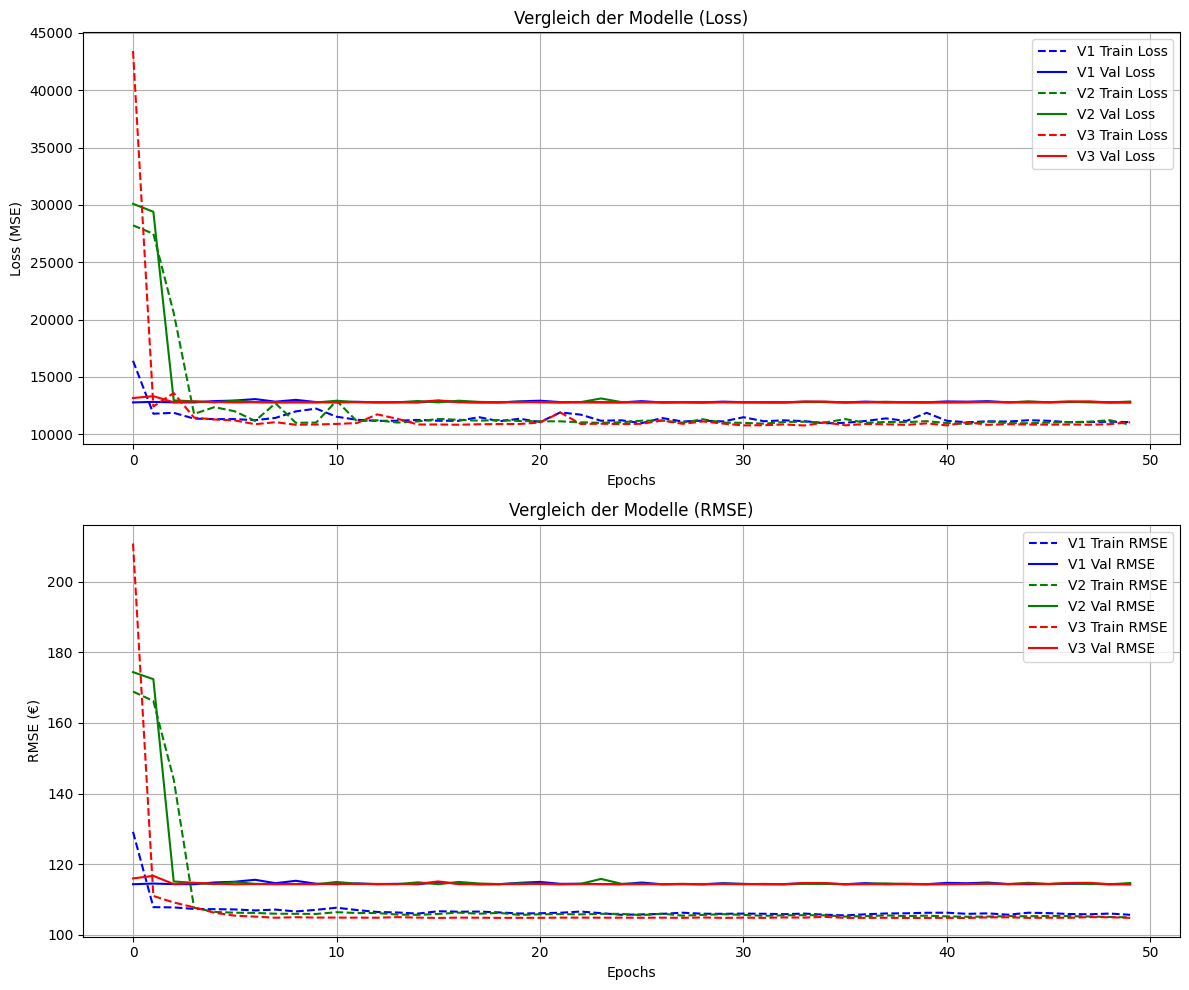


--- Beste Ergebnisse (Validation RMSE) ---
Modell V1: Bester Epoch 27 | Val RMSE: 114.34€
Modell V2: Bester Epoch 22 | Val RMSE: 114.34€
Modell V3: Bester Epoch 31 | Val RMSE: 114.34€

🏆 GEWINNER: Modell V3 mit einem RMSE von 114.34€


In [17]:

fig, axs = plt.subplots(2, 1, figsize=(12, 10))

# 1. PLOT: LOSS (MSE)
axs[0].plot(train_losses_V1, label='V1 Train Loss', linestyle='--', color='blue')
axs[0].plot(val_losses_V1, label='V1 Val Loss', color='blue')

axs[0].plot(train_losses_V2, label='V2 Train Loss', linestyle='--', color='green')
axs[0].plot(val_losses_V2, label='V2 Val Loss', color='green')

axs[0].plot(train_losses_V3, label='V3 Train Loss', linestyle='--', color='red')
axs[0].plot(val_losses_V3, label='V3 Val Loss', color='red')

axs[0].set_title('Vergleich der Modelle (Loss)')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss (MSE)')
axs[0].legend()
axs[0].grid(True)

# 2. PLOT: RMSE
axs[1].plot(train_rmses_V1, label='V1 Train RMSE', linestyle='--', color='blue')
axs[1].plot(val_rmses_V1, label='V1 Val RMSE', color='blue')

axs[1].plot(train_rmses_V2, label='V2 Train RMSE', linestyle='--', color='green')
axs[1].plot(val_rmses_V2, label='V2 Val RMSE', color='green')

axs[1].plot(train_rmses_V3, label='V3 Train RMSE', linestyle='--', color='red')
axs[1].plot(val_rmses_V3, label='V3 Val RMSE', color='red')

axs[1].set_title('Vergleich der Modelle (RMSE)')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('RMSE (€)')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

# --- BESTE EPOCHS FINDEN ---
print("\n--- Beste Ergebnisse (Validation RMSE) ---")

best_epoch_V1 = np.argmin(val_rmses_V1)
best_rmse_V1 = val_rmses_V1[best_epoch_V1]
print(f"Modell V1: Bester Epoch {best_epoch_V1+1} | Val RMSE: {best_rmse_V1:.2f}€")

best_epoch_V2 = np.argmin(val_rmses_V2)
best_rmse_V2 = val_rmses_V2[best_epoch_V2]
print(f"Modell V2: Bester Epoch {best_epoch_V2+1} | Val RMSE: {best_rmse_V2:.2f}€")

best_epoch_V3 = np.argmin(val_rmses_V3)
best_rmse_V3 = val_rmses_V3[best_epoch_V3]
print(f"Modell V3: Bester Epoch {best_epoch_V3+1} | Val RMSE: {best_rmse_V3:.2f}€")

# Gewinner ermitteln
winner = min([(best_rmse_V1, 'V1'), (best_rmse_V2, 'V2'), (best_rmse_V3, 'V3')])
print(f"\n🏆 GEWINNER: Modell {winner[1]} mit einem RMSE von {winner[0]:.2f}€")

Starte Hyperparameter-Test für 4 Learning Rates...

--- Teste Learning Rate: 0.1 ---
Ergebnis LR 0.1: Finaler Val Loss (MSE) = 12783.0822

--- Teste Learning Rate: 0.01 ---
Ergebnis LR 0.01: Finaler Val Loss (MSE) = 12779.6546

--- Teste Learning Rate: 0.001 ---
Ergebnis LR 0.001: Finaler Val Loss (MSE) = 12794.2005

--- Teste Learning Rate: 0.0001 ---
Ergebnis LR 0.0001: Finaler Val Loss (MSE) = 28673.6423


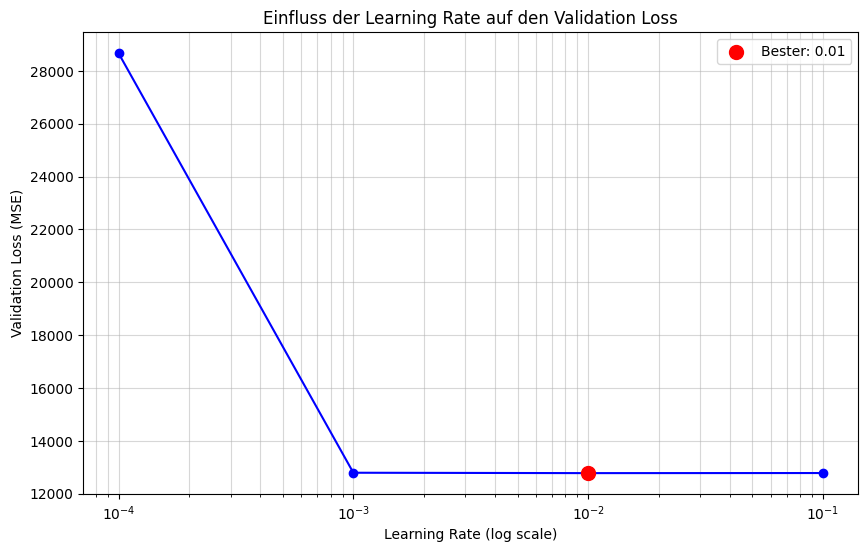

Starte Hyperparameter-Test für 4 Learning Rates...

--- Teste Learning Rate: 0.1 ---
Ergebnis LR 0.1: Finaler Val Loss (MSE) = 12816.2261

--- Teste Learning Rate: 0.01 ---
Ergebnis LR 0.01: Finaler Val Loss (MSE) = 12827.7080

--- Teste Learning Rate: 0.001 ---
Ergebnis LR 0.001: Finaler Val Loss (MSE) = 12793.1105

--- Teste Learning Rate: 0.0001 ---
Ergebnis LR 0.0001: Finaler Val Loss (MSE) = 27683.2575


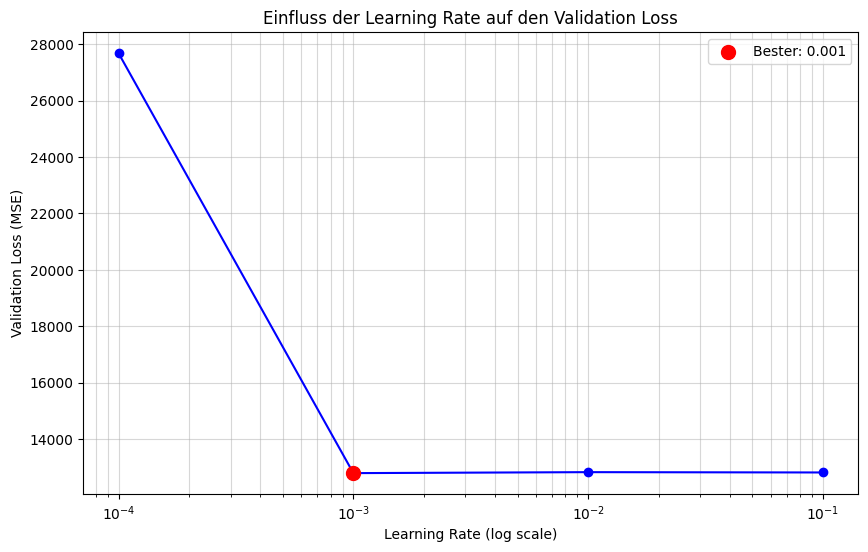

Starte Hyperparameter-Test für 4 Learning Rates...

--- Teste Learning Rate: 0.1 ---
Ergebnis LR 0.1: Finaler Val Loss (MSE) = 12790.2565

--- Teste Learning Rate: 0.01 ---
Ergebnis LR 0.01: Finaler Val Loss (MSE) = 12873.9741

--- Teste Learning Rate: 0.001 ---
Ergebnis LR 0.001: Finaler Val Loss (MSE) = 12787.7835

--- Teste Learning Rate: 0.0001 ---
Ergebnis LR 0.0001: Finaler Val Loss (MSE) = 27979.2777


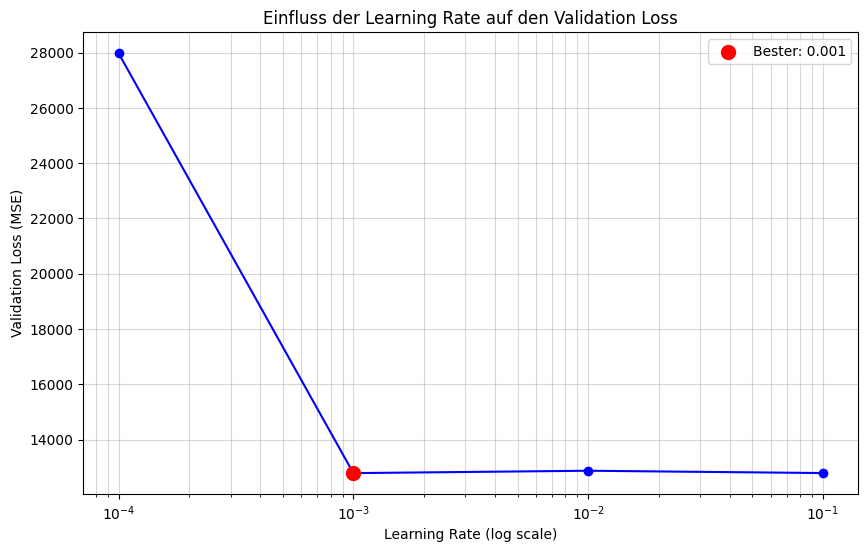

In [18]:
learning_rates = [0.1,0.01,0.001,0.0001]

best_lr_V1, best_loss_V2 = test_learning_rates(
    learning_rates=learning_rates,
    model_class=MLPModel,
    input_dim=512,
    output_dim=1,
    train_loader=train_loader_img,
    val_loader=val_loader_img,
    device=device,
    epochs=50
)

best_lr_V1, best_loss_V2 = test_learning_rates(
    learning_rates=learning_rates,
    model_class=MLPModel,
    input_dim=512,
    output_dim=1,
    train_loader=train_loader_img,
    val_loader=val_loader_img,
    device=device,
    epochs=50
)

best_lr_V3, best_loss_V3 = test_learning_rates(
    learning_rates=learning_rates,
    model_class=MLPModel,
    input_dim=512,
    output_dim=1,
    train_loader=train_loader_img,
    val_loader=val_loader_img,
    device=device,
    epochs=50
)

